In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score,confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import joblib
import sklearn


In [2]:

# Load the processed data from note 1
df = pd.read_csv('cleaned_heart_data.csv')
# Now you can work with the clean data immediately

In [3]:

X = df.drop('target', axis=1)
y = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Define feature types
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# 4. Set up Scikit-Learn Pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. Split and Process Data for ML
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


Number of components needed to explain 95% of variance: 14


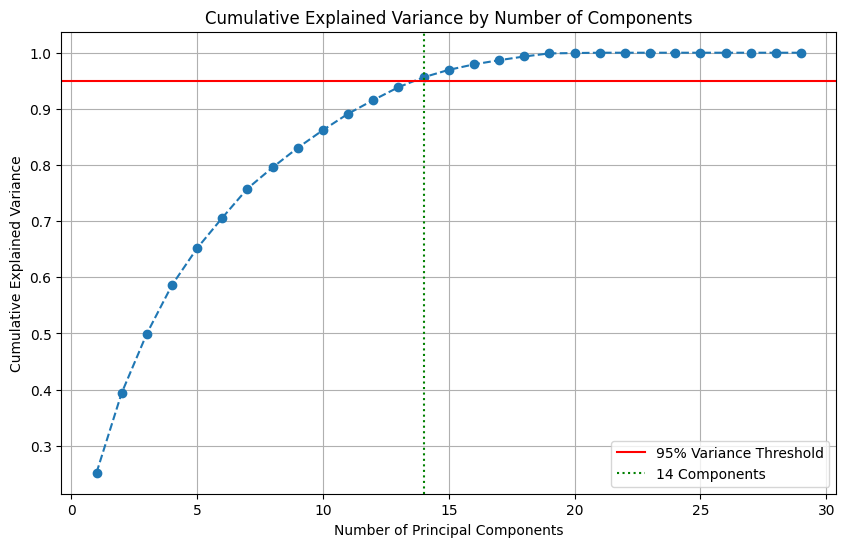

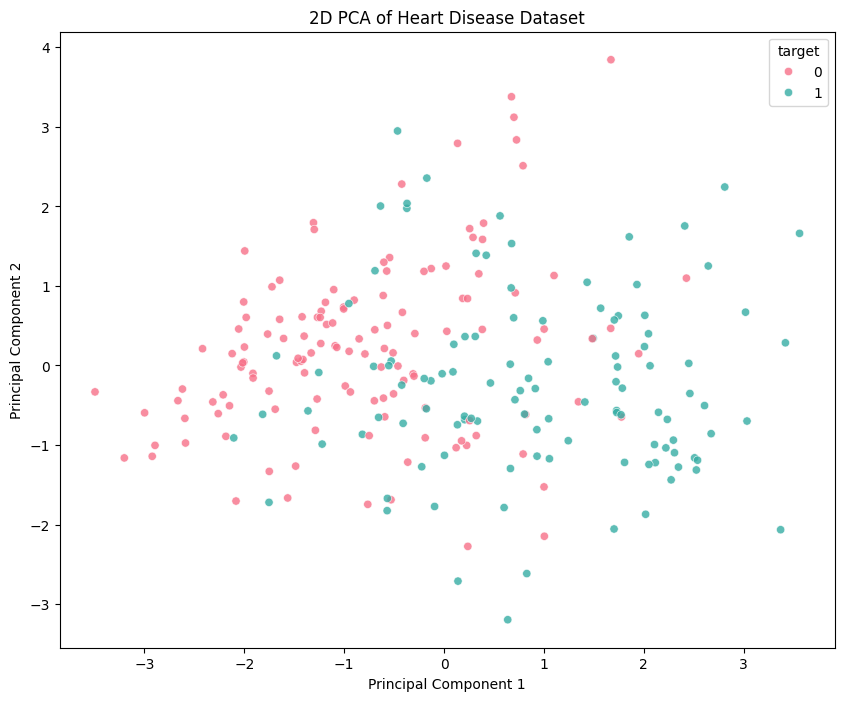

In [4]:
pca = PCA()
pca.fit(X_train_processed)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Number of components needed to explain 95% of variance: {n_components_95}")



plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Number of Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)

plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variance Threshold')
plt.axvline(x=n_components_95, color='g', linestyle=':', label=f'{n_components_95} Components')
plt.legend()
plt.show()



pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_processed)


df_pca = pd.DataFrame(data=X_train_pca_2d, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['target'] = y_train.values 


plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1', y='Principal Component 2',
    hue='target',
    palette=sns.color_palette("husl", 2),
    data=df_pca,
    legend="full",
    alpha=0.8
)
plt.title('2D PCA of Heart Disease Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()